# data clean

In [1]:
import pandas as pd
df = pd.read_csv('players.csv')
display(df.head(2))

,player_id,player_name,nationality,dob_year,batting_style,bowling_style,playing_role,ipl_debut_season,last_season_played,is_capped_international,base_price_lakh,highest_auction_price_lakh
0,P0001,Umesh Cummins,India,1981,Right-hand bat,NaN,Batsman,2008,2018,True,75,100
1,P0002,Jofra Natarajan,South Africa,1991,Right-hand bat,Slow left-arm orthodox,Bowler,2011,2019,False,100,405


In [2]:
print(f"data shpe : {df.shape}")
print('-'*40)
print(f"null : \n{df.isnull().sum()}")
print('-'*40)
print(f'duplicate data : {df.duplicated().sum()}')

data shpe : (580, 12)
----------------------------------------
null : 
player_id                       0
player_name                     0
nationality                     0
dob_year                        0
batting_style                   0
bowling_style                 287
playing_role                    0
ipl_debut_season                0
last_season_played              0
is_capped_international         0
base_price_lakh                 0
highest_auction_price_lakh      0
dtype: int64
----------------------------------------
duplicate data : 0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   player_id                   580 non-null    object
 1   player_name                 580 non-null    object
 2   nationality                 580 non-null    object
 3   dob_year                    580 non-null    int64 
 4   batting_style               580 non-null    object
 5   bowling_style               293 non-null    object
 6   playing_role                580 non-null    object
 7   ipl_debut_season            580 non-null    int64 
 8   last_season_played          580 non-null    int64 
 9   is_capped_international     580 non-null    bool  
 10  base_price_lakh             580 non-null    int64 
 11  highest_auction_price_lakh  580 non-null    int64 
dtypes: bool(1), int64(5), object(6)
memory usage: 50.5+ KB


In [4]:
df[df['playing_role'] == 'Batsman']['bowling_style'].isnull().mean()

np.float64(1.0)

In [5]:
df[df['playing_role'] != 'Batsman']['bowling_style'].isnull().mean()

np.float64(0.21657754010695188)

In [6]:
df['playing_role'].value_counts()

playing_role
Batsman                 206
Bowler                  165
All-Rounder             128
Wicketkeeper-Batsman     81
Name: count, dtype: int64

In [7]:
# Only assign where it is logically valid
mask = df['playing_role'].isin(['Batsman', 'Wicketkeeper-Batsman']) & df['bowling_style'].isnull()

df.loc[mask, 'bowling_style'] = 'No Bowling'

In [8]:
df['bowling_style'].value_counts()

bowling_style
No Bowling                287
Slow left-arm orthodox     36
Left-arm fast-medium       36
Right-arm leg break        31
Right-arm medium           28
Right-arm fast             28
Left-arm fast              26
Left-arm orthodox          26
Left-arm wrist spin        23
Right-arm fast-medium      22
Right-arm offbreak         22
Left-arm medium            15
Name: count, dtype: int64

In [9]:
df.isnull().sum()

player_id                     0
player_name                   0
nationality                   0
dob_year                      0
batting_style                 0
bowling_style                 0
playing_role                  0
ipl_debut_season              0
last_season_played            0
is_capped_international       0
base_price_lakh               0
highest_auction_price_lakh    0
dtype: int64

In [10]:
import numpy as np
numeric_col = df.select_dtypes(include=['int64' , 'float64'])
numeric_col.columns.tolist()

['dob_year',
 'ipl_debut_season',
 'last_season_played',
 'base_price_lakh',
 'highest_auction_price_lakh']

In [11]:
df.to_csv('clean_data.csv')

# feture engineering

In [12]:
print(df['base_price_lakh'].skew())
print(df['highest_auction_price_lakh'].skew())

0.5173139469928544
1.2926771991942851


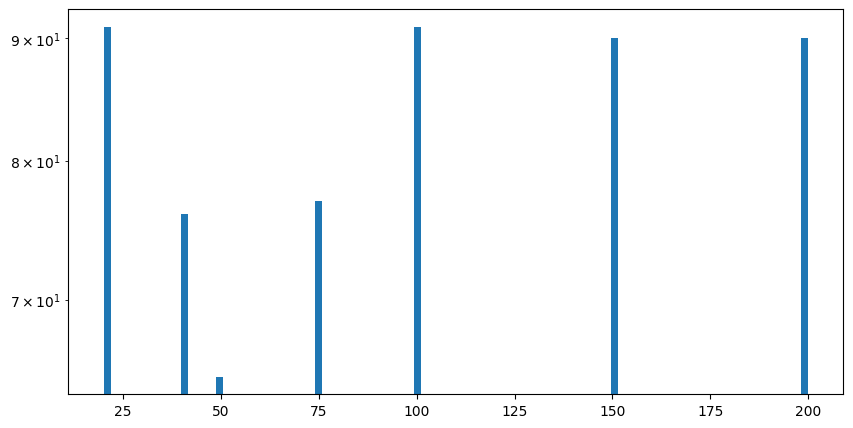

In [13]:
import matplotlib.pyplot as plt
df['base_price_lakh'].describe()

plt.figure(figsize=(10,5))
plt.hist(df['base_price_lakh'],bins=100)
plt.yscale('log')
plt.show()

In [15]:
current_year = 2025
df['age'] = current_year - df['dob_year']

# player experiance
df["ipl_experience"] = df["last_season_played"] - df["ipl_debut_season"]

# log transformation
df["log_highest_price"] = np.log1p(df["highest_auction_price_lakh"])

# binary feature
df["is_capped_international"] = df["is_capped_international"].map({True: 1, False: 0,"True": 1, "False": 0})



In [16]:
df = df.drop(columns=['player_id' , 'player_name','dob_year','ipl_debut_season','last_season_played'])

In [18]:
df = df.drop(columns=['nationality'])

In [25]:
df = df.drop(columns=['playing_role_enc','batting_style_enc','bowling_style_enc'])

In [27]:
df.to_csv('ml_model_data.csv',index=False)